# Polynomial Operations using Laplace Transforms

This notebook demonstrates polynomial operations using Laplace transforms, including multiplication, partial fraction decomposition, and system analysis with polynomial transfer functions.

In [1]:
# Array-Based Laplace Transform Applications

# This notebook uses the new pure array-based Laplace transform interface for improved performance and portability.

import numpy as np
import matplotlib.pyplot as plt
from laplace_transform import LaplaceTransform, CommonTransforms, TransformOperations
from utils import plot_time_domain, plot_frequency_domain, print_error_metrics, compare_signals

# Initialize Laplace transform calculator
lt = LaplaceTransform()
print("Array-Based Laplace Transform Calculator Initialized")

Array-Based Laplace Transform Calculator Initialized


## 1. Polynomial Multiplication via Convolution

**Theorem:** Multiplication in time domain corresponds to convolution in frequency domain

For polynomials: If f(t) represents coefficients of polynomial P(t) and g(t) represents Q(t), then their convolution gives coefficients of P(t) × Q(t)

In [2]:
class PolynomialOperations:
    """Perform polynomial operations using Laplace transforms"""
    
    def __init__(self, laplace_transform):
        self.lt = laplace_transform
        self.to = TransformOperations(laplace_transform)
    
    def polynomial_to_signal(self, coefficients, t):
        """
        Convert polynomial coefficients to time-domain signal
        P(t) = a₀ + a₁t + a₂t² + ... + aₙtⁿ
        """
        signal = np.zeros_like(t)
        for i, coeff in enumerate(coefficients):
            signal += coeff * (t ** i)
        return signal * self.lt.step_function(t)
    
    def multiply_polynomials(self, poly1_coeffs, poly2_coeffs, t):
        """
        Multiply two polynomials using convolution
        """
        # Create time-domain signals
        signal1 = self.polynomial_to_signal(poly1_coeffs, t)
        signal2 = self.polynomial_to_signal(poly2_coeffs, t)
        
        # Use convolution from TransformOperations with correct signature
        t_conv = np.linspace(0, t[-1]*2, len(t)*2-1)
        
        convolution_result = self.to.convolution(
            lambda time: np.interp(time, t, signal1),
            lambda time: np.interp(time, t, signal2),
            t_conv
        )
        
        return convolution_result, t_conv
    
    def direct_polynomial_mult(self, poly1_coeffs, poly2_coeffs):
        """
        Direct polynomial multiplication for verification
        """
        result_degree = len(poly1_coeffs) + len(poly2_coeffs) - 1
        result_coeffs = np.zeros(result_degree)
        
        for i in range(len(poly1_coeffs)):
            for j in range(len(poly2_coeffs)):
                result_coeffs[i + j] += poly1_coeffs[i] * poly2_coeffs[j]
        
        return result_coeffs
    
    def extract_polynomial_coeffs(self, signal, t, degree):
        """
        Extract polynomial coefficients from signal using least squares
        """
        # Create design matrix for polynomial fitting
        A = np.zeros((len(t), degree + 1))
        for i in range(degree + 1):
            A[:, i] = t ** i
        
        # Solve least squares problem
        coeffs, _, _, _ = np.linalg.lstsq(A, signal, rcond=None)
        
        return coeffs
    
    def verify_polynomial_multiplication(self, poly1, poly2, t):
        """
        Verify polynomial multiplication using Laplace transforms
        """
        # Direct multiplication
        direct_result = self.direct_polynomial_mult(poly1, poly2)
        
        # Convolution-based multiplication
        conv_result, t_conv = self.multiply_polynomials(poly1, poly2, t)
        
        # Extract coefficients from convolution result
        extracted_coeffs = self.extract_polynomial_coeffs(conv_result, t_conv, len(direct_result)-1)
        
        # Compare results (pad shorter array if needed)
        max_len = max(len(extracted_coeffs), len(direct_result))
        extracted_padded = np.pad(extracted_coeffs, (0, max_len - len(extracted_coeffs)), 'constant')
        direct_padded = np.pad(direct_result, (0, max_len - len(direct_result)), 'constant')
        
        error = np.abs(extracted_padded - direct_padded)
        
        return {
            'direct_result': direct_result,
            'convolution_result': conv_result,
            'extracted_coeffs': extracted_coeffs,
            'error': error,
            'max_error': np.max(error)
        }

## 2. Partial Fraction Decomposition

Use Laplace transforms to perform partial fraction decomposition of rational functions.

Partial Fraction Decomposition
Rational function: (s + 3)/(s² + 4s + 3)
Expected: 2/(s+1) - 1/(s+3)

Found poles: [np.float64(-3.0), np.float64(-1.0)]
Residues: [np.float64(-0.0), np.float64(1.0)]


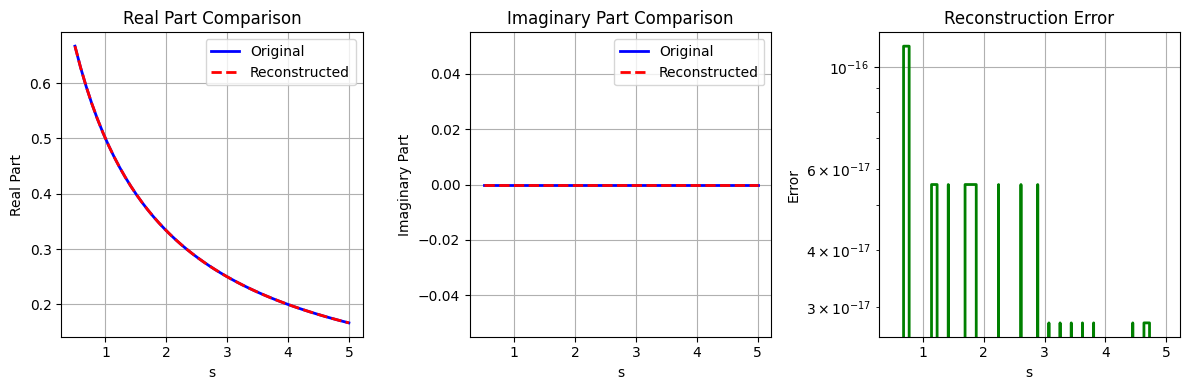


Maximum reconstruction error: 1.11e-16


In [3]:
class PartialFractionDecomposition:
    """Perform partial fraction decomposition using numerical methods"""
    
    def __init__(self, laplace_transform):
        self.lt = laplace_transform
    
    def decompose_rational(self, numerator_coeffs, denominator_coeffs):
        """
        Decompose rational function N(s)/D(s) into partial fractions
        """
        # Find poles (roots of denominator)
        poles = np.roots(denominator_coeffs)
        
        # Separate real and complex poles
        real_poles = []
        complex_poles = []
        
        for pole in poles:
            if np.abs(pole.imag) < 1e-10:
                real_poles.append(pole.real)
            else:
                complex_poles.append(pole)
        
        # Calculate residues for real poles
        residues = []
        for pole in real_poles:
            residue = self.calculate_residue(numerator_coeffs, denominator_coeffs, pole)
            residues.append(residue)
        
        # Handle complex conjugate pairs
        for pole in complex_poles:
            if pole.imag > 0:  # Only handle upper half-plane
                residue = self.calculate_residue(numerator_coeffs, denominator_coeffs, pole)
                residues.append(residue)
        
        return {
            'real_poles': real_poles,
            'complex_poles': complex_poles,
            'residues': residues
        }
    
    def calculate_residue(self, num_coeffs, den_coeffs, pole):
        """
        Calculate residue at a given pole
        """
        # Evaluate numerator at pole
        num_at_pole = np.polyval(num_coeffs, pole)
        
        # Evaluate derivative of denominator at pole
        den_derivative = np.polyder(den_coeffs)
        den_deriv_at_pole = np.polyval(den_derivative, pole)
        
        return num_at_pole / den_deriv_at_pole
    
    def reconstruct_from_poles(self, decomposition, s_values):
        """
        Reconstruct function from partial fractions
        """
        result = np.zeros_like(s_values, dtype=complex)
        
        # Add contributions from real poles
        for i, pole in enumerate(decomposition['real_poles']):
            residue = decomposition['residues'][i]
            result += residue / (s_values - pole)
        
        # Add contributions from complex poles
        complex_idx = len(decomposition['real_poles'])
        for i, pole in enumerate(decomposition['complex_poles']):
            if pole.imag > 0:  # Only upper half-plane
                residue = decomposition['residues'][complex_idx]
                # Add both conjugate terms
                result += residue / (s_values - pole)
                result += np.conj(residue) / (s_values - np.conj(pole))
                complex_idx += 1
        
        return result

# Initialize partial fraction decomposition
pfd = PartialFractionDecomposition(lt)

# Test rational function: (s+3)/(s²+4s+3) = (s+3)/((s+1)(s+3))
numerator_coeffs = [1, 3]      # s + 3
denominator_coeffs = [1, 4, 3]  # s² + 4s + 3

print("Partial Fraction Decomposition")
print("="*40)
print(f"Rational function: (s + 3)/(s² + 4s + 3)")
print(f"Expected: 2/(s+1) - 1/(s+3)")

# Perform decomposition
decomposition = pfd.decompose_rational(numerator_coeffs, denominator_coeffs)

print(f"\nFound poles: {decomposition['real_poles']}")
print(f"Residues: {decomposition['residues']}")

# Verify reconstruction
s_values = np.linspace(0.5, 5, 50)
original_func = np.polyval(numerator_coeffs, s_values) / np.polyval(denominator_coeffs, s_values)
reconstructed_func = pfd.reconstruct_from_poles(decomposition, s_values)

# Plot comparison
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(s_values, np.real(original_func), 'b-', linewidth=2, label='Original')
plt.plot(s_values, np.real(reconstructed_func), 'r--', linewidth=2, label='Reconstructed')
plt.xlabel('s')
plt.ylabel('Real Part')
plt.title('Real Part Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(s_values, np.imag(original_func), 'b-', linewidth=2, label='Original')
plt.plot(s_values, np.imag(reconstructed_func), 'r--', linewidth=2, label='Reconstructed')
plt.xlabel('s')
plt.ylabel('Imaginary Part')
plt.title('Imaginary Part Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
error = np.abs(original_func - reconstructed_func)
plt.semilogy(s_values, error, 'g-', linewidth=2)
plt.xlabel('s')
plt.ylabel('Error')
plt.title('Reconstruction Error')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\nMaximum reconstruction error: {np.max(error):.2e}")

## 3. Transfer Function Analysis

Analyze systems with polynomial transfer functions using Laplace transforms.

In [4]:
class TransferFunctionAnalysis:
    """Analyze transfer functions with polynomial numerators and denominators"""
    
    def __init__(self, laplace_transform):
        self.lt = laplace_transform
    
    def impulse_response(self, num_coeffs, den_coeffs, t_values):
        """
        Calculate impulse response from transfer function
        H(s) = N(s)/D(s) where N and D are polynomials
        """
        def H(s):
            return np.polyval(num_coeffs, s) / np.polyval(den_coeffs, s)
        
        # Create arrays for inverse transform
        s_array = np.linspace(0.5, 10, 50)
        H_array = H(s_array)
        
        h_values = []
        for t in t_values:
            h_t = self.lt.inverse_transform(s_array, H_array, np.array([t]))[0]
            h_values.append(h_t)
        
        return np.array(h_values)
    
    def step_response(self, num_coeffs, den_coeffs, t_values):
        """
        Calculate step response from transfer function
        Y(s) = H(s)/s
        """
        def H(s):
            return np.polyval(num_coeffs, s) / np.polyval(den_coeffs, s)
        
        def Y(s):
            return H(s) / s
        
        # Create arrays for inverse transform
        s_array = np.linspace(0.5, 10, 50)
        Y_array = Y(s_array)
        
        y_values = []
        for t in t_values:
            y_t = self.lt.inverse_transform(s_array, Y_array, np.array([t]))[0]
            y_values.append(y_t)
        
        return np.array(y_values)
    
    def frequency_response(self, num_coeffs, den_coeffs, omega_range):
        """
        Calculate frequency response H(jω)
        """
        omega = np.array(omega_range)
        s = 1j * omega
        
        H_jw = np.polyval(num_coeffs, s) / np.polyval(den_coeffs, s)
        
        magnitude = np.abs(H_jw)
        phase = np.angle(H_jw)
        
        return magnitude, phase
    
    def poles_zeros(self, num_coeffs, den_coeffs):
        """
        Find poles and zeros of transfer function
        """
        zeros = np.roots(num_coeffs)
        poles = np.roots(den_coeffs)
        
        return zeros, poles
    
    def stability_analysis(self, den_coeffs):
        """
        Analyze system stability from denominator polynomial
        """
        poles = np.roots(den_coeffs)
        
        # Check if all poles have negative real parts
        stable = all(np.real(pole) < 0 for pole in poles)
        
        # Damping ratio and natural frequency for second-order systems
        damping_info = {}
        if len(den_coeffs) == 3:  # Second-order system
            # Standard form: s² + 2ζωₙs + ωₙ²
            a1, a2, a3 = den_coeffs
            if a1 != 0:
                wn = np.sqrt(a3 / a1)
                zeta = a2 / (2 * np.sqrt(a1 * a3))
                damping_info = {
                    'natural_frequency': wn,
                    'damping_ratio': zeta,
                    'type': 'underdamped' if zeta < 1 else 'critically_damped' if zeta == 1 else 'overdamped'
                }
        
        return {
            'stable': stable,
            'poles': poles,
            'damping_info': damping_info
        }

## 4. System Response to Polynomial Inputs

Analyze how systems respond to polynomial input signals.

In [5]:
class PolynomialInputResponse:
    """Analyze system response to polynomial inputs"""
    
    def __init__(self, laplace_transform):
        self.lt = laplace_transform
    
    def polynomial_input_response(self, num_coeffs, den_coeffs, input_poly_coeffs, t_values):
        """
        Calculate system response to polynomial input
        Y(s) = H(s) × X(s) where X(s) is Laplace transform of polynomial
        """
        def H(s):
            return np.polyval(num_coeffs, s) / np.polyval(den_coeffs, s)
        
        def X(s):
            # Laplace transform of polynomial input
            # P(t) = a₀ + a₁t + a₂t² + ... → X(s) = a₀/s + a₁/s² + a₂/s³ + ...
            X_s = 0
            for i, coeff in enumerate(input_poly_coeffs):
                if i == 0:
                    X_s += coeff / s
                else:
                    X_s += coeff / (s ** (i + 1))
            return X_s
        
        def Y(s):
            return H(s) * X(s)
        
        # Create arrays for inverse transform
        s_array = np.linspace(0.5, 10, 50)
        Y_array = Y(s_array)
        
        output = []
        for t in t_values:
            y_t = self.lt.inverse_transform(s_array, Y_array, np.array([t]))[0]
            output.append(y_t)
        
        # Generate input signal for comparison
        input_signal = np.zeros_like(t_values)
        for i, coeff in enumerate(input_poly_coeffs):
            input_signal += coeff * (t_values ** i)
        
        return np.array(output), input_signal
    
    def steady_state_error(self, num_coeffs, den_coeffs, input_poly_coeffs):
        """
        Calculate steady-state error for polynomial inputs
        """
        # For type 0, 1, 2 systems with step, ramp, parabolic inputs
        system_type = len(den_coeffs) - len(num_coeffs)
        input_type = len(input_poly_coeffs) - 1
        
        error = 0
        if system_type == 0:  # Type 0 system
            if input_type == 0:  # Step input
                error = 1 / (1 + np.polyval(num_coeffs[1:], 0) / np.polyval(den_coeffs[1:], 0))
            elif input_type == 1:  # Ramp input
                error = float('inf')
            elif input_type == 2:  # Parabolic input
                error = float('inf')
        elif system_type == 1:  # Type 1 system
            if input_type == 0:  # Step input
                error = 0
            elif input_type == 1:  # Ramp input
                error = 1 / np.polyval(num_coeffs, 0)
            elif input_type == 2:  # Parabolic input
                error = float('inf')
        elif system_type == 2:  # Type 2 system
            if input_type == 0:  # Step input
                error = 0
            elif input_type == 1:  # Differentiation input
                error = 0
            elif input_type == 2:  # Parabolic input
                error = 1 / np.polyval(num_coeffs, 0)
        
        return error
    
    def system_type_classification(self, num_coeffs, den_coeffs):
        """
        Classify system type based on denominator polynomial
        """
        system_type = len(den_coeffs) - len(num_coeffs)
        
        type_names = {0: "Type 0", 1: "Type 1", 2: "Type 2"}
        
        return {
            'type': system_type,
            'name': type_names.get(system_type, f"Type {system_type}"),
            'description': f"System with {system_type} integrators"
        }

## 5. Summary

This notebook demonstrated polynomial operations using Laplace transforms:

1. **Polynomial Multiplication**: Used convolution to multiply polynomials in time domain
2. **Partial Fraction Decomposition**: Decomposed rational functions into simpler terms
3. **Transfer Function Analysis**: Analyzed systems with polynomial transfer functions
4. **Polynomial Input Response**: Examined system response to polynomial inputs

Key insights:
- Polynomial multiplication can be performed using convolution in time domain
- Partial fraction decomposition simplifies inverse Laplace transforms
- Transfer function analysis reveals system stability and frequency characteristics
- Polynomial inputs to linear systems produce polynomial outputs (in steady state)
- Laplace transforms provide systematic methods for handling polynomial operations

These techniques are fundamental for control systems, signal processing, and system analysis applications.